In [17]:
'''
isFever > 100
    yes > cough?
        yes > flu
        no > maybe
    No - No Flu

1-Overfitting
2-Underfitting
3-Perfect Fit
'''

'\nisFever > 100\n    yes > cough?\n        yes > flu\n        no > maybe\n    No - No Flu\n\n1-Overfitting\n2-Underfitting\n3-Perfect Fit\n'

### Decision Tree Classifier 

#### 1.`Import` Libraries 

In [18]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [19]:
# X = [
#     [7,2],  #Apple
#     [8,3],  #Apple
#     [9,8],  #Orange
#     [10,9]  #Orange
# ]
# Y = [0,0,1,1]  # 0 = Apple, 1 = Orange

# model = DecisionTreeClassifier()
# model.fit(X,Y)

# size = float(input("Enter Fruit size in cm: "))
# colorShade = float(input("Enter Fruit color shade (1-10): "))

# result = model.predict([[size,colorShade]])[0]
# print(result)

# if result == 0:
#     print("Fruit is Apple")
# else:
#     print("Fruit is Orange")

#### 2.`load` Data set

In [20]:
data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
                "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                    "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
             "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    "PlayTennis": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                   "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}
df = pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


####  3. `Encode` Categorical Features

In [21]:
# One encoder per column
encoders = {}
for col in ["Outlook", "Temperature", "Humidity", "Wind"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le   # save encoder for later use

df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,No
1,2,1,0,0,No
2,0,1,0,1,Yes
3,1,2,0,1,Yes
4,1,0,1,1,Yes
5,1,0,1,0,No
6,0,0,1,0,Yes
7,2,2,0,1,No
8,2,0,1,1,Yes
9,1,2,1,1,Yes


#### 4.`Split` Features and Target

In [22]:
# Features and target
X = df[["Outlook", "Temperature", "Humidity", "Wind"]]
y = df["PlayTennis"]

#### 5.`Train Test Split`

In [ ]:
# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

#### 6.`Train` Decision Tree Model

In [23]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
clf.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 7.`Encode` New Input & Predict

In [24]:
sample = [[
    encoders["Outlook"].transform(["Sunny"])[0],
    encoders["Temperature"].transform(["Cool"])[0],
    encoders["Humidity"].transform(["High"])[0],
    encoders["Wind"].transform(["Strong"])[0]
]]

pred = clf.predict(sample)
print("Prediction:", pred[0])


Prediction: No


c:\Users\Abdul Rehman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### 8.`Visualize` Tree

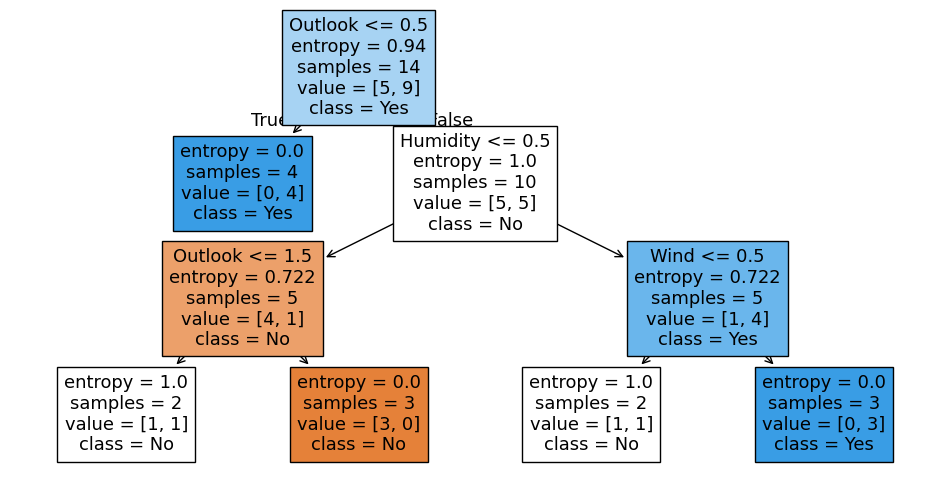

In [25]:
# Visualize
plt.figure(figsize=(12,6))
plot_tree(clf, feature_names=["Outlook", "Temperature", "Humidity", "Wind"], 
          class_names=clf.classes_, filled=True)
plt.show()

### Decision Tree (On Iris Dataset)

Test Accuracy: 0.9555555555555556


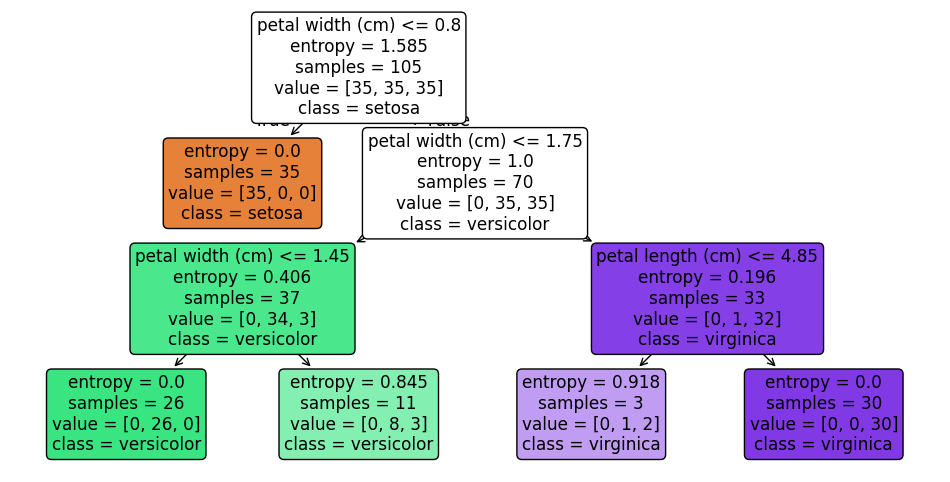

Prediction for sample: setosa


In [26]:


# Step 1: Load dataset
iris = load_iris()
X = iris.data   # features: sepal length, sepal width, petal length, petal width
y = iris.target # class labels: 0,1,2 (Setosa, Versicolor, Virginica)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

# Step 3: Train decision tree
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
clf.fit(X_train, y_train)

# Step 4: Evaluate
y_pred = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Step 5: Visualize tree
plt.figure(figsize=(12,6))
plot_tree(clf, feature_names=iris.feature_names, 
          class_names=iris.target_names, filled=True, rounded=True)
plt.show()

# Step 6: Single prediction example
sample = [[5.0, 3.6, 1.4, 0.2]]   # Sepal length, width, petal length, width
print("Prediction for sample:", iris.target_names[clf.predict(sample)[0]])


### Decision Tree (With Train-Test Split)